In [3]:
# Creating required folders for the project structure

import os

folders = [
    "/content/Internship_Work/botswana_dataset",
    "/content/Internship_Work/forest_dataset",
    "/content/Internship_Work/notebooks",
    "/content/Internship_Work/plots",
]

for f in folders:
    os.makedirs(f, exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [4]:
# Checking number of images in Botswana dataset

import os

path = "/content/Internship_Work/botswana_dataset"
files = os.listdir(path)

print("Total Images:", len(files))
print("Sample files:", files[:5])

Total Images: 50
Sample files: ['DSC_0061.JPG', 'DSC_0029.JPG', 'DSC_0049.JPG', 'DSC_0034.JPG', 'DSC_0058.JPG']


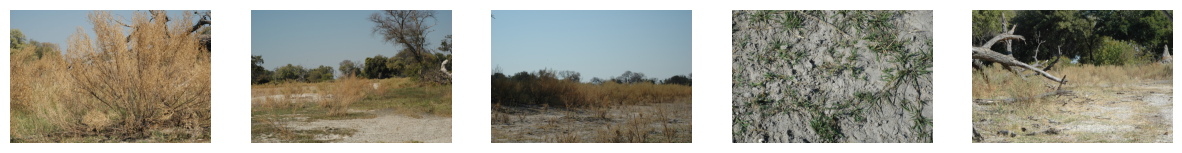

In [8]:
# Loading a few sample images and displaying them

import os
import cv2
import matplotlib.pyplot as plt

# Path
dataset_path = "/content/Internship_Work/botswana_dataset"

# Get image files
image_files = os.listdir(dataset_path)

# Load 5 images
images = []
for file in image_files[:5]:
    img = cv2.imread(os.path.join(dataset_path, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)

# Display images
plt.figure(figsize=(15,5))
for i, img in enumerate(images):
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.savefig("/content/Internship_Work/plots/sample_images.png")
plt.show()

In [9]:
# Checking basic properties of an image

img = images[0]

print("Shape:", img.shape)
print("Min pixel value:", img.min())
print("Max pixel value:", img.max())
img = images[0]

print("Shape:", img.shape)       # Shape of image = (height, width, 3)
print("Min pixel value:", img.min())
print("Max pixel value:", img.max())

Shape: (2000, 3008, 3)
Min pixel value: 0
Max pixel value: 255
Shape: (2000, 3008, 3)
Min pixel value: 0
Max pixel value: 255


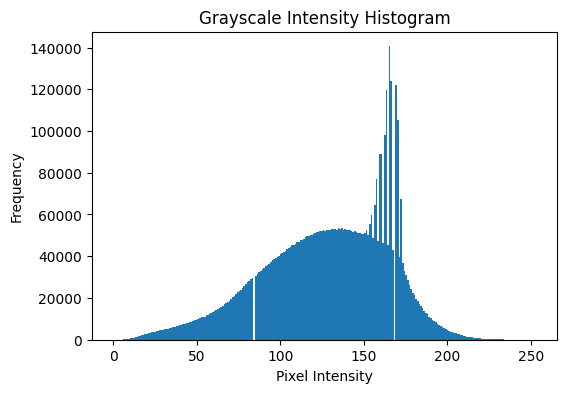

In [10]:
import numpy as np

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Plot histogram
plt.figure(figsize=(6,4))
plt.hist(gray.ravel(), bins=256)
plt.title("Grayscale Intensity Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

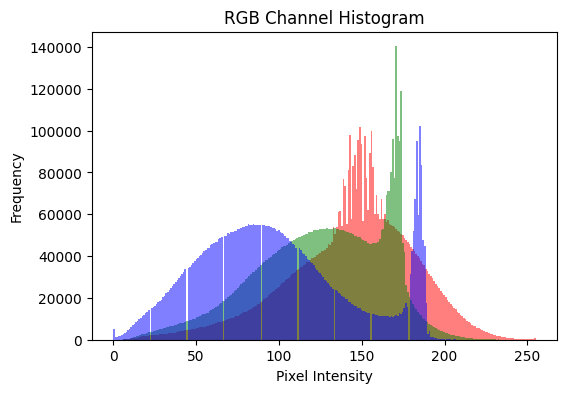

In [11]:
# Plotting histogram for each RGB channel

colors = ['r', 'g', 'b']

plt.figure(figsize=(6,4))
for i, color in enumerate(colors):
    plt.hist(img[:,:,i].ravel(), bins=256, color=color, alpha=0.5)

plt.title("RGB Channel Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

In [12]:
import numpy as np

# Take grayscale image
gray = cv2.cvtColor(images[0], cv2.COLOR_RGB2GRAY)

# Shift image by 1 pixel (right)
right_shift = gray[:, 1:]
left_part = gray[:, :-1]

# Flatten arrays
x = left_part.flatten()
y = right_shift.flatten()

# Correlation
corr = np.corrcoef(x, y)[0,1]
print("Horizontal Neighbor Correlation:", corr)

Horizontal Neighbor Correlation: 0.9238123335271956


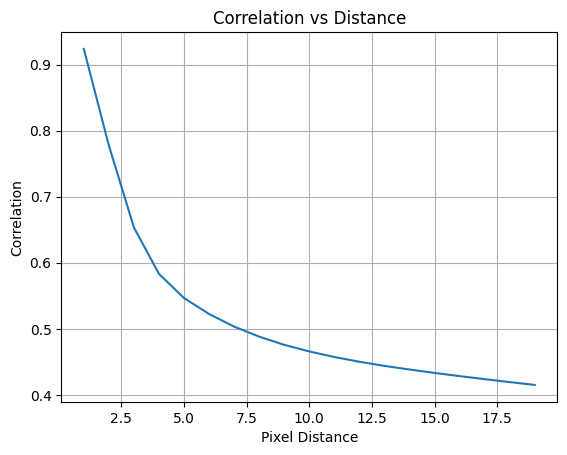

In [13]:
# Observing how correlation changes with pixel distance

distances = range(1, 20)
correlations = []

for d in distances:
    left = gray[:, :-d]
    right = gray[:, d:]

    x = left.flatten()
    y = right.flatten()

    corr = np.corrcoef(x, y)[0,1]
    correlations.append(corr)

# Plot
import matplotlib.pyplot as plt

plt.plot(distances, correlations)
plt.title("Correlation vs Distance")
plt.xlabel("Pixel Distance")
plt.ylabel("Correlation")
plt.grid()
plt.show()

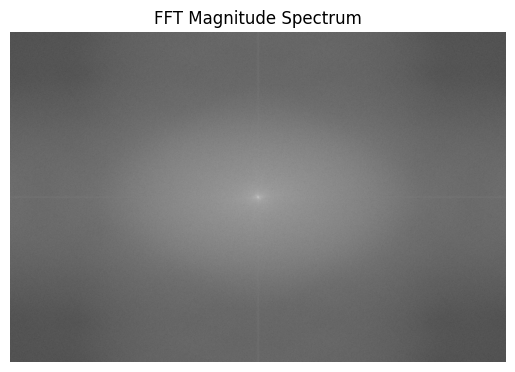

In [14]:
# Performing frequency analysis using FFT

f = np.fft.fft2(gray)
fshift = np.fft.fftshift(f)

magnitude = np.log(np.abs(fshift) + 1)

plt.imshow(magnitude, cmap='gray')
plt.title("FFT Magnitude Spectrum")
plt.axis('off')
plt.show()

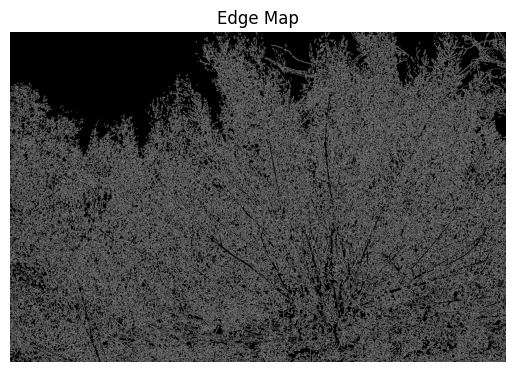

Edge Density: 0.23443533909574468


In [15]:
# Detecting edges and calculating edge density

edges = cv2.Canny(gray, 100, 200)

plt.imshow(edges, cmap='gray')
plt.title("Edge Map")
plt.axis('off')
plt.show()

edge_density = np.sum(edges > 0) / edges.size
print("Edge Density:", edge_density)

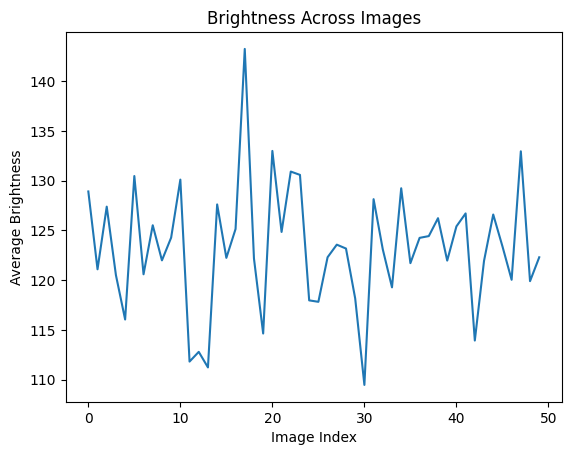

In [16]:
# Calculating average brightness for each image in the dataset

brightness_values = []

for file in image_files:
    img = cv2.imread(os.path.join(dataset_path, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    brightness_values.append(np.mean(gray))

plt.plot(brightness_values)
plt.title("Brightness Across Images")
plt.xlabel("Image Index")
plt.ylabel("Average Brightness")
plt.show()

Average Correlation: 0.9673097321565111


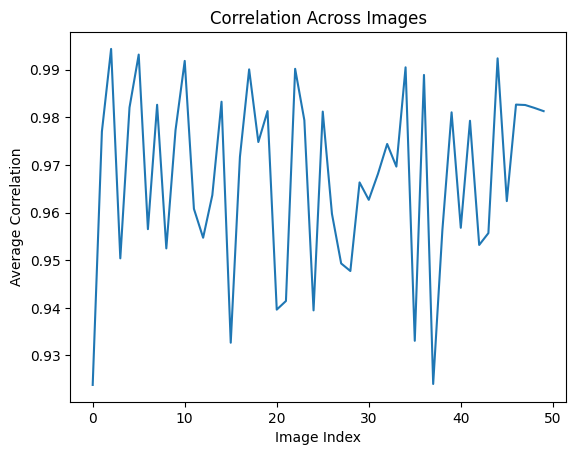

In [19]:
# Computing correlation between neighboring pixels for all images

correlations = []

for file in image_files:
    img = cv2.imread(os.path.join(dataset_path, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    left = gray[:, :-1]
    right = gray[:, 1:]

    corr = np.corrcoef(left.flatten(), right.flatten())[0,1]
    correlations.append(corr)

# Calculating average correlation across dataset

print("Average Correlation:", np.mean(correlations))

# Showing Correlation Plot
plt.plot(correlations)
plt.title("Correlation Across Images")
plt.xlabel("Image Index")
plt.ylabel("Average Correlation")
plt.show()

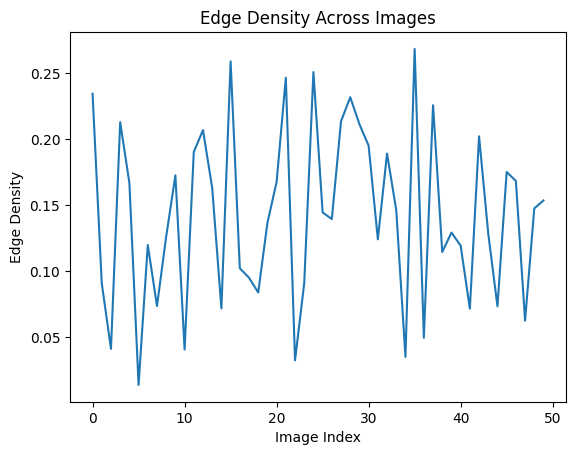

In [20]:
# Calculating edge density for each image to measure texture complexity

edge_densities = []

for file in image_files:
    img = cv2.imread(os.path.join(dataset_path, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)

    density = np.sum(edges > 0) / edges.size
    edge_densities.append(density)

plt.plot(edge_densities)
plt.title("Edge Density Across Images")
plt.xlabel("Image Index")
plt.ylabel("Edge Density")
plt.show()

In [21]:
# Checking number of images in Botswana dataset

import os

path = "/content/Internship_Work/botswana_dataset"
files = os.listdir(path)

print("Total Images:", len(files))


# Checking total number of images in Forest dataset

import os

path = "/content/Internship_Work/forest_dataset"
files = os.listdir(path)

print("Total Images:", len(files))

Total Images: 50
Sample files: ['DSC_0061.JPG', 'DSC_0029.JPG', 'DSC_0049.JPG', 'DSC_0034.JPG', 'DSC_0058.JPG']
Total Images: 50
Sample files: ['43.jpg', '20.jpg', '28.jpg', '8.jpg', '22.jpg']


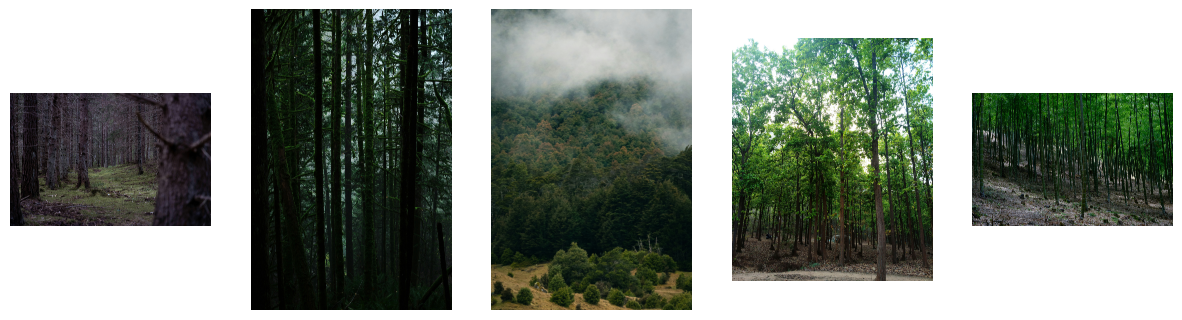

In [22]:
# Loading a few sample images from forest dataset and displaying them

import os
import cv2
import matplotlib.pyplot as plt

# Path
dataset_path = "/content/Internship_Work/forest_dataset"

# Get image files
image_files = os.listdir(dataset_path)

# Load 5 images
images = []
for file in image_files[:5]:
    img = cv2.imread(os.path.join(dataset_path, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)

# Display images
plt.figure(figsize=(15,5))
for i, img in enumerate(images):
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.savefig("/content/Internship_Work/plots/sample_images2.png")
plt.show()

Setting up both paths, now we will compare the Botswana Dataset with Indian Forest Dataset

In [24]:
botswana_path = "/content/Internship_Work/botswana_dataset"
forest_path = "/content/Internship_Work/forest_dataset"

botswana_files = os.listdir(botswana_path)
forest_files = os.listdir(forest_path)

In [25]:
import numpy as np
import cv2

# Function to compute key image statistics for a dataset
def compute_metrics(path, files):
    brightness = []
    correlation = []
    edge_density = []

    for file in files:
        # Reading image and converting to RGB format
        img = cv2.imread(os.path.join(path, file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Converting image to grayscale for analysis
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        # Brightness
        brightness.append(np.mean(gray))

        # Correlation
        left = gray[:, :-1]
        right = gray[:, 1:]
        corr = np.corrcoef(left.flatten(), right.flatten())[0,1]
        correlation.append(corr)

        # Edge Density
        edges = cv2.Canny(gray, 100, 200)
        density = np.sum(edges > 0) / edges.size
        edge_density.append(density)

    # Returning all computed metrics
    return brightness, correlation, edge_density

In [29]:
# Applying the function on both datasets

b_brightness, b_corr, b_edge = compute_metrics(botswana_path, botswana_files)
i_brightness, i_corr, i_edge = compute_metrics(forest_path, forest_files)

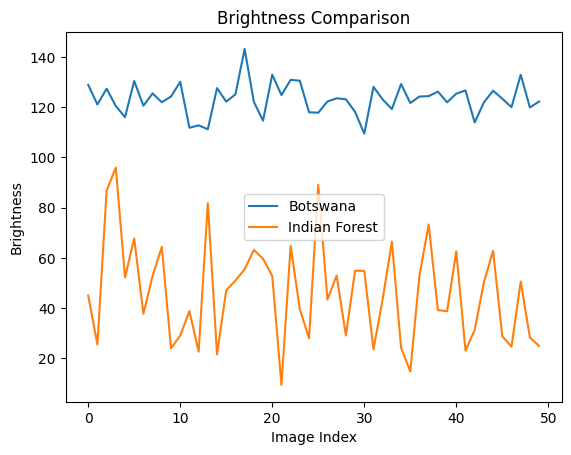

In [30]:
# Comparing average brightness between Botswana and Indian forest datasets

import matplotlib.pyplot as plt

plt.plot(b_brightness, label="Botswana")
plt.plot(i_brightness, label="Indian Forest")
plt.legend()
plt.title("Brightness Comparison")
plt.xlabel("Image Index")
plt.ylabel("Brightness")
plt.show()

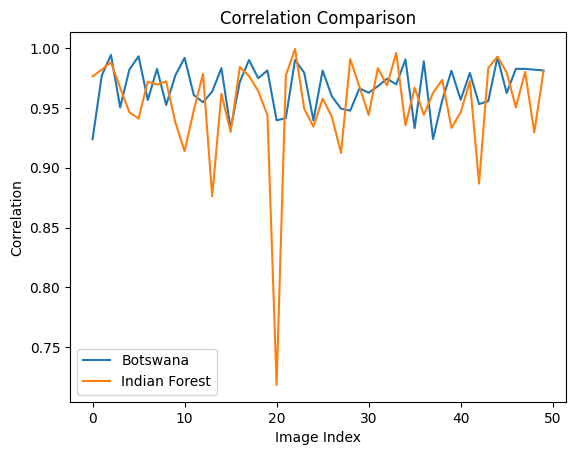

In [31]:
# Comparing spatial correlation between neighboring pixels for both datasets

plt.plot(b_corr, label="Botswana")
plt.plot(i_corr, label="Indian Forest")
plt.legend()
plt.title("Correlation Comparison")
plt.xlabel("Image Index")
plt.ylabel("Correlation")
plt.show()

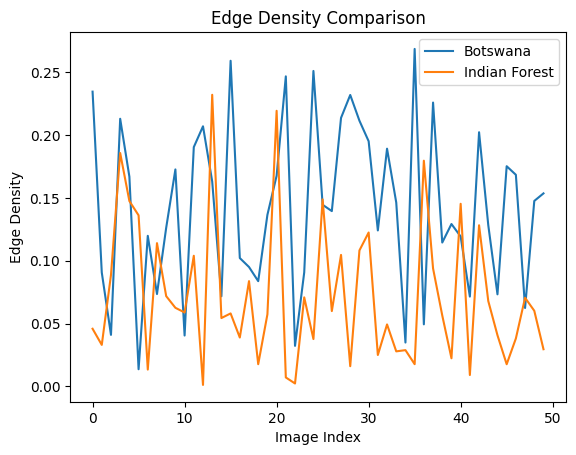

In [32]:
# Comparing edge density to measure texture complexity in both datasets

plt.plot(b_edge, label="Botswana")
plt.plot(i_edge, label="Indian Forest")
plt.legend()
plt.title("Edge Density Comparison")
plt.xlabel("Image Index")
plt.ylabel("Edge Density")
plt.show()

Now Training Binary Data Classifier for Botswana vs Indian forest Classification

Imports

In [33]:
# Import required libraries
import os
import cv2
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Defining Paths

In [34]:
# Define dataset paths
botswana_path = "/content/Internship_Work/botswana_dataset"
forest_path = "/content/Internship_Work/forest_dataset"

Feature Extraction Function

In [35]:
# Function to extract features from image
def extract_features(img):

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- Feature 1: Mean Brightness ---
    brightness = np.mean(gray)

    # --- Feature 2: Standard Deviation ---
    std_dev = np.std(gray)

    # --- Feature 3: Edge Density ---
    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size

    # --- Feature 4: Horizontal Correlation ---
    left = gray[:, :-1]
    right = gray[:, 1:]
    corr = np.corrcoef(left.flatten(), right.flatten())[0, 1]

    return [brightness, std_dev, edge_density, corr]

Loading Data + Creating Feature Vectors

In [37]:
# Store features and labels
X = []
y = []

# --- Botswana images (label = 0) ---
for file in os.listdir(botswana_path):
    img = cv2.imread(os.path.join(botswana_path, file))
    features = extract_features(img)
    X.append(features)
    y.append(0)

# --- Indian forest images (label = 1) ---
for file in os.listdir(forest_path):
    img = cv2.imread(os.path.join(forest_path, file))
    features = extract_features(img)
    X.append(features)
    y.append(1)

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)

Feature shape: (100, 4)


Train-Test Split

In [38]:
# Split into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 80
Testing samples: 20


Train Classifier

In [39]:
# Train Logistic Regression model
model = LogisticRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


Predictions

In [40]:
# Predict on test data
y_pred = model.predict(X_test)

In [41]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Confusion Matrix:

[[12  0]
 [ 0  8]]


# ===============================
# Category-wise Analysis (Intel Dataset)
# ===============================

In [45]:
# Upload kaggle.json file from your system

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"akashconnects","key":"7b222d1534c7b6bd5de87f3c031313b4"}'}

In [46]:
# Create kaggle folder and move API key there
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/

# Set proper permissions (required)
!chmod 600 ~/.kaggle/kaggle.json

In [47]:
# Install kaggle package
!pip install kaggle

# Download Intel image classification dataset
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:05<00:00, 64.3MB/s]



In [48]:
# Extract downloaded zip file
import zipfile

with zipfile.ZipFile("intel-image-classification.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/intel_dataset")

Category wise Analysis

In [49]:
# Base path where dataset is extracted
base_path = "/content/intel_dataset/seg_train/seg_train"

# Get all categories (folders like forest, sea, etc.)
import os
categories = os.listdir(base_path)

print("Categories:", categories)

Categories: ['glacier', 'sea', 'street', 'mountain', 'buildings', 'forest']


In [50]:
import numpy as np
import cv2

# Store results for each category
category_results = {}

for category in categories:

    path = os.path.join(base_path, category)
    files = os.listdir(path)

    brightness = []
    correlation = []
    edge_density = []

    # Loop through images (limit for speed)
    for file in files[:50]:

        img = cv2.imread(os.path.join(path, file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Convert to grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        # --- Brightness ---
        brightness.append(np.mean(gray))

        # --- Neighbor Pixel Correlation ---
        left = gray[:, :-1]
        right = gray[:, 1:]
        corr = np.corrcoef(left.flatten(), right.flatten())[0,1]
        correlation.append(corr)

        # --- Edge Density ---
        edges = cv2.Canny(gray, 100, 200)
        density = np.sum(edges > 0) / edges.size
        edge_density.append(density)

    # Store average values for this category
    category_results[category] = {
        "brightness": np.mean(brightness),
        "correlation": np.mean(correlation),
        "edge_density": np.mean(edge_density)
    }

In [51]:
# Print results category-wise
for cat, values in category_results.items():
    print(f"\nCategory: {cat}")
    print(f"Brightness: {values['brightness']:.2f}")
    print(f"Correlation: {values['correlation']:.3f}")
    print(f"Edge Density: {values['edge_density']:.3f}")


Category: glacier
Brightness: 133.32
Correlation: 0.886
Edge Density: 0.165

Category: sea
Brightness: 126.15
Correlation: 0.929
Edge Density: 0.149

Category: street
Brightness: 98.81
Correlation: 0.822
Edge Density: 0.205

Category: mountain
Brightness: 122.73
Correlation: 0.915
Edge Density: 0.142

Category: buildings
Brightness: 115.15
Correlation: 0.794
Edge Density: 0.217

Category: forest
Brightness: 84.78
Correlation: 0.629
Edge Density: 0.311


In [52]:
import matplotlib.pyplot as plt

# Prepare data for plotting
cats = list(category_results.keys())
brightness_vals = [category_results[c]["brightness"] for c in cats]
corr_vals = [category_results[c]["correlation"] for c in cats]
edge_vals = [category_results[c]["edge_density"] for c in cats]


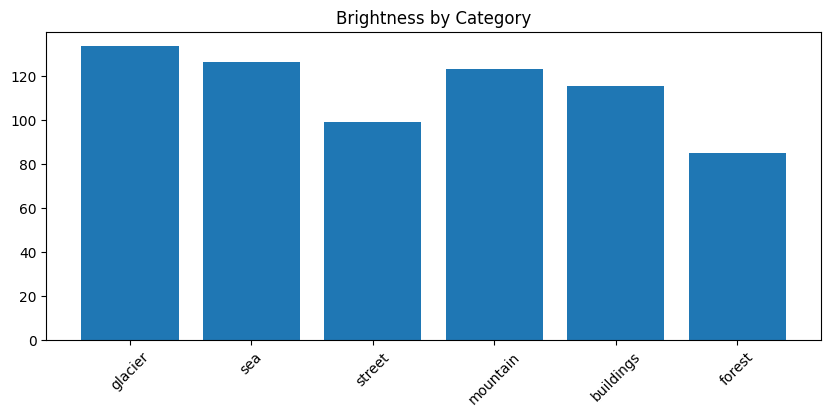

In [53]:
# --- Brightness Plot ---
plt.figure(figsize=(10,4))
plt.bar(cats, brightness_vals)
plt.title("Brightness by Category")
plt.xticks(rotation=45)
plt.show()

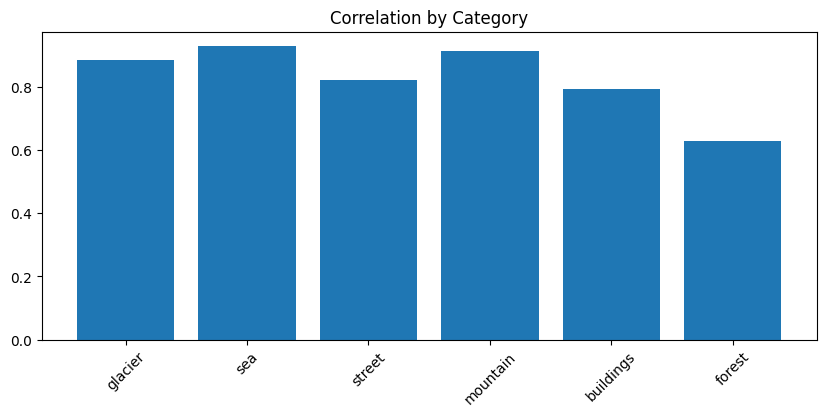

In [54]:
# --- Correlation Plot ---
plt.figure(figsize=(10,4))
plt.bar(cats, corr_vals)
plt.title("Correlation by Category")
plt.xticks(rotation=45)
plt.show()

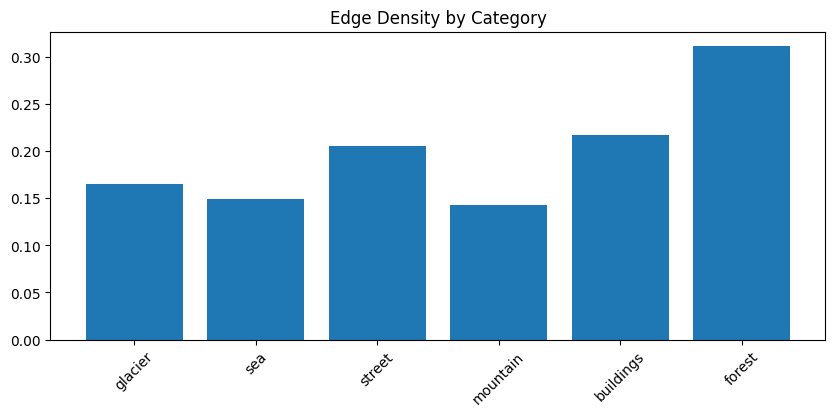

In [55]:
# --- Edge Density Plot ---
plt.figure(figsize=(10,4))
plt.bar(cats, edge_vals)
plt.title("Edge Density by Category")
plt.xticks(rotation=45)
plt.show()

Training a multi-class classifier to categorize the images

In [56]:
# Import libraries
import os
import cv2
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [57]:
# Base path of Intel dataset
base_path = "/content/intel_dataset/seg_train/seg_train"

# Get category names
categories = os.listdir(base_path)
print("Categories:", categories)

Categories: ['glacier', 'sea', 'street', 'mountain', 'buildings', 'forest']


In [58]:
# Extract features from image
def extract_features(img):

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Brightness
    brightness = np.mean(gray)

    # Standard deviation
    std_dev = np.std(gray)

    # Edge density
    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size

    # Correlation
    left = gray[:, :-1]
    right = gray[:, 1:]
    corr = np.corrcoef(left.flatten(), right.flatten())[0,1]

    return [brightness, std_dev, edge_density, corr]

In [59]:
# Prepare data
X = []
y = []

# Assign numeric labels to categories
label_map = {cat: i for i, cat in enumerate(categories)}

for category in categories:

    path = os.path.join(base_path, category)
    files = os.listdir(path)

    for file in files[:100]:  # limit for speed

        img = cv2.imread(os.path.join(path, file))
        features = extract_features(img)

        X.append(features)
        y.append(label_map[category])

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)
print("Labels:", label_map)

Feature shape: (600, 4)
Labels: {'glacier': 0, 'sea': 1, 'street': 2, 'mountain': 3, 'buildings': 4, 'forest': 5}


In [76]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [77]:
# Feature scaling (improves stability)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [78]:
# Logistic Regression model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    multi_class='multinomial',
    solver='lbfgs'
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [79]:
# Predict
y_pred = model.predict(X_test)

In [80]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.525

Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.43      0.47        23
           1       0.40      0.40      0.40        20
           2       0.43      0.63      0.51        19
           3       0.38      0.29      0.33        17
           4       0.53      0.47      0.50        17
           5       0.83      0.83      0.83        24

    accuracy                           0.53       120
   macro avg       0.51      0.51      0.51       120
weighted avg       0.53      0.53      0.52       120

Confusion Matrix:

[[10  7  1  5  0  0]
 [ 6  8  2  3  0  1]
 [ 2  0 12  0  3  2]
 [ 1  4  3  5  4  0]
 [ 1  0  7  0  8  1]
 [ 0  1  3  0  0 20]]
